# Классификация и регрессия: эксперименты

Ноутбук к теме [`lesson.md`](lesson.md). Каждый раздел проверяет одно утверждение лекции на данных, а не на словах.

1. Ловушка условного среднего — почему MSE-регрессия ломается на бимодальной цели
2. Сколько брать бинов при переводе регрессии в классификацию
3. Порядковая цель: регрессия против «K независимых классов»
4. Номинальные метки, закодированные числами — почему так нельзя
5. Вероятность → класс: порог как отдельное решение

Запуск: `.venv/bin/python -m jupyter lab` из корня репозитория, либо любой IDE с ядром из `.venv`.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import f1_score, mean_absolute_error, precision_recall_curve
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import SplineTransformer

# палитра проекта
C_BG, C_INK, C_GRAY = "#faf9f5", "#141413", "#b0aea5"
C_PANEL, C_ORANGE, C_BLUE, C_GREEN = "#e8e6dc", "#d97757", "#6a9bcc", "#788c5d"
plt.rcParams.update({
    "figure.facecolor": C_BG, "axes.facecolor": C_BG,
    "axes.edgecolor": C_GRAY, "text.color": C_INK,
    "xtick.color": C_INK, "ytick.color": C_INK,
    "axes.labelcolor": C_INK, "font.size": 11, "legend.frameon": False,
})

def rmse(a, b):
    return float(np.sqrt(np.mean((np.asarray(a) - np.asarray(b)) ** 2)))

## 1. Ловушка условного среднего

Строим цель, у которой при каждом `x` два режима. MSE-регрессия обязана предсказывать $E[y \mid x]$ — а среднее двух мод лежит между ними, то есть там, где данных нет.

In [2]:
rng = np.random.default_rng(7)
n = 2000
x = rng.uniform(0, 10, n)
up = rng.random(n) < 0.5
y = np.where(up, 1.6 * x + 4.0, -1.6 * x + 26.0) + rng.normal(0, 1.1, n)
X = x[:, None]

reg = LinearRegression().fit(X, y)
pred_at_5 = float(reg.predict([[5.0]])[0])

# сколько реальных объектов лежит рядом с предсказанием?
near_slice = np.abs(x - 5.0) < 0.5
ys = y[near_slice]
close = np.mean(np.abs(ys - pred_at_5) < 1.0)

print(f"предсказание регрессии при x=5:   {pred_at_5:.2f}")
print(f"реальные моды при x=5:            {ys[ys < pred_at_5].mean():.2f} и {ys[ys > pred_at_5].mean():.2f}")
print(f"доля объектов в пределах ±1 от предсказания: {close:.1%}")

предсказание регрессии при x=5:   14.97
реальные моды при x=5:            11.87 и 17.87
доля объектов в пределах ±1 от предсказания: 6.7%


Предсказание попадает в зазор между модами: рядом с ним почти нет наблюдений. Теперь то же самое, но как классификация по бинам — она возвращает распределение, а не точку.

In [3]:
def bin_target(y_tr, n_bins):
    """Границы по квантилям + центры как средние цели внутри бина."""
    edges = np.quantile(y_tr, np.linspace(0, 1, n_bins + 1))
    edges[0] -= 1e-9
    edges[-1] += 1e-9
    cls = np.clip(np.digitize(y_tr, edges[1:-1]), 0, n_bins - 1)
    centers = np.array([
        y_tr[cls == k].mean() if np.any(cls == k) else 0.0 for k in range(n_bins)
    ])
    return edges, cls, centers

edges, cls, centers = bin_target(y, 12)
clf = make_pipeline(
    SplineTransformer(n_knots=10, degree=3),
    LogisticRegression(max_iter=4000, C=5.0),
).fit(X, cls)

proba_at_5 = clf.predict_proba([[5.0]])[0]
top = np.argsort(proba_at_5)[::-1][:4]
print("Классификатор при x=5 — четыре самых вероятных бина:")
for k in top:
    bin_id = clf.classes_[k]
    print(f"  центр {centers[bin_id]:6.2f}   p = {proba_at_5[k]:.2f}")

Классификатор при x=5 — четыре самых вероятных бина:
  центр  11.50   p = 0.23
  центр  18.42   p = 0.21
  центр  12.94   p = 0.16
  центр  16.98   p = 0.16


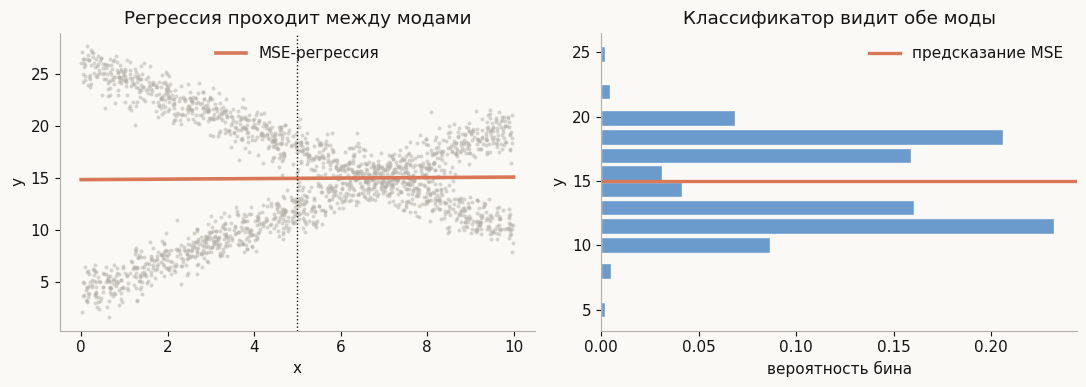

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
ax.scatter(x, y, s=8, color=C_GRAY, alpha=0.5, linewidths=0)
grid = np.linspace(0, 10, 200)
ax.plot(grid, reg.predict(grid[:, None]), color=C_ORANGE, lw=2.6, label="MSE-регрессия")
ax.axvline(5.0, color=C_INK, lw=1.0, ls=":")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.legend(loc="upper center")
ax.set_title("Регрессия проходит между модами")

ax = axes[1]
order = np.argsort(clf.classes_)
ax.barh(centers[clf.classes_[order]], proba_at_5[order], height=1.2,
        color=C_BLUE, edgecolor=C_BG)
ax.axhline(pred_at_5, color=C_ORANGE, lw=2.4, label="предсказание MSE")
ax.set_xlabel("вероятность бина")
ax.set_ylabel("y")
ax.set_title("Классификатор видит обе моды")
ax.legend(loc="upper right")

for a in axes:
    for side in ("top", "right"):
        a.spines[side].set_visible(False)
fig.tight_layout()

## 2. Сколько брать бинов

Перевод регрессии в классификацию имеет цену: слишком мало бинов — грубое разрешение, слишком много — мало объектов на бин и шумные вероятности. Проверяем на гладкой унимодальной цели и сравниваем с прямой регрессией.

In [5]:
NOISE = 0.8

def make_wave(n, seed=3):
    r = np.random.default_rng(seed)
    xx = r.uniform(-3, 3, (n, 1))
    yy = np.sin(xx.ravel() * 1.4) * 4 + xx.ravel() + r.normal(0, NOISE, n)
    return xx, yy

def binned_rmse(n_bins, x_tr, y_tr, x_te, y_te):
    """Классификатор по бинам, декодированный обратно в число через E[y]."""
    _, cls_tr, cent = bin_target(y_tr, n_bins)
    if len(np.unique(cls_tr)) < 2:
        return np.nan
    m = make_pipeline(
        SplineTransformer(n_knots=12, degree=3),
        LogisticRegression(max_iter=4000, C=5.0),
    ).fit(x_tr, cls_tr)
    decoded = m.predict_proba(x_te) @ cent[m.classes_]
    return rmse(decoded, y_te)

bins = [2, 3, 4, 6, 8, 12, 16, 24, 32, 48, 64]
n_test = 400
curves = {}
for n_train in (150, 2000):
    xx, yy = make_wave(n_train + n_test)
    xtr, ytr, xte, yte = xx[:n_train], yy[:n_train], xx[n_train:], yy[n_train:]
    curves[n_train] = [binned_rmse(k, xtr, ytr, xte, yte) for k in bins]

xx, yy = make_wave(150 + n_test)
direct = make_pipeline(SplineTransformer(n_knots=12, degree=3), LinearRegression())
direct.fit(xx[:150], yy[:150])
direct_rmse = rmse(direct.predict(xx[150:]), yy[150:])

print(f"{'K':>4} {'RMSE @150':>11} {'RMSE @2000':>12}")
for i, k in enumerate(bins):
    print(f"{k:>4} {curves[150][i]:>11.3f} {curves[2000][i]:>12.3f}")
print(f"\nлучший биннинг на 150 объектах:  {min(curves[150]):.3f} (K={bins[int(np.argmin(curves[150]))]})")
print(f"прямая регрессия на 150 объектах: {direct_rmse:.3f}")
print(f"неустранимый шум:                 {NOISE:.3f}")

   K   RMSE @150   RMSE @2000
   2       1.699        1.573
   3       1.033        1.014
   4       1.087        0.926
   6       1.022        0.855
   8       0.994        0.856
  12       1.021        0.859
  16       1.088        0.860
  24       1.205        0.868
  32       1.316        0.878
  48       1.527        0.899
  64       1.693        0.919

лучший биннинг на 150 объектах:  0.994 (K=8)
прямая регрессия на 150 объектах: 0.910
неустранимый шум:                 0.800


На гладкой унимодальной цели прямая регрессия выигрывает у любого биннинга: квантование только теряет разрешение. Биннинг окупается там, где нужна форма распределения — как в разделе 1.

## 3. Порядковая цель: регрессия против «K независимых классов»

Рейтинг 1–5 звёзд дискретен, но упорядочен. Многоклассовая классификация об этом порядке не знает и штрафует промах на 1 звезду так же, как на 4. Вопрос — насколько это дорого обходится на практике.

Меряем MAE двух подходов на сетке «объём обучения × число градаций», усредняя по 12 запускам, чтобы не ловить шум одного сплита.

In [6]:
def ordinal_trial(n_train, n_levels, seed, noise=0.7):
    """Одна и та же порядковая цель, решённая двумя способами. Возвращает (MAE_класс, MAE_регр)."""
    r = np.random.default_rng(seed)
    n = n_train + 400
    Xo = r.normal(0, 1, (n, 4))
    latent = Xo @ np.array([1.2, -0.8, 0.5, 0.3]) + r.normal(0, noise, n)
    cuts = np.quantile(latent, np.linspace(0, 1, n_levels + 1)[1:-1])
    yo = np.clip(np.digitize(latent, cuts) + 1, 1, n_levels)
    tr, te = slice(0, n_train), slice(n_train, n)

    as_cls = LogisticRegression(max_iter=3000).fit(Xo[tr], yo[tr])
    as_reg = Ridge(alpha=1.0).fit(Xo[tr], yo[tr])
    pred_reg = np.clip(np.rint(as_reg.predict(Xo[te])), 1, n_levels)
    return (mean_absolute_error(yo[te], as_cls.predict(Xo[te])),
            mean_absolute_error(yo[te], pred_reg))

print(f"{'градаций':>9} {'обучение':>9} | {'MAE класс':>10} {'MAE регр':>9}   выигрыш регрессии")
for n_levels in (5, 10):
    for n_train in (60, 150, 800):
        mc, mr = np.mean([ordinal_trial(n_train, n_levels, s) for s in range(12)], axis=0)
        gain = (mc - mr) / mc
        print(f"{n_levels:>9} {n_train:>9} | {mc:>10.3f} {mr:>9.3f}   {gain:>+8.1%}")

 градаций  обучение |  MAE класс  MAE регр   выигрыш регрессии
        5        60 |      0.621     0.522     +16.0%
        5       150 |      0.533     0.491      +7.7%
        5       800 |      0.456     0.487      -6.9%


       10        60 |      1.437     1.043     +27.4%
       10       150 |      1.255     1.000     +20.3%
       10       800 |      1.020     0.977      +4.2%


Результат тоньше, чем «регрессия всегда лучше на порядковых целях». Преимущество порядкового подхода — это **экономия данных**:

- при 60–150 объектах регрессия выигрывает заметно: знание порядка заменяет   ей недостающие примеры;
- при 5 градациях и 800 объектах многоклассовая классификация **обгоняет**   регрессию — данных на каждый класс хватает, чтобы выучить порядок самой,   а округление непрерывного предсказания начинает мешать;
- при 10 градациях регрессия впереди даже на 800 объектах: объектов на класс   вдвое меньше, и цена незнания порядка снова высока.

Правило: чем меньше объектов на одну градацию, тем ценнее закладывать порядок в постановку задачи. Отдельно стоит помнить, что классификация оптимизирует долю точных попаданий, а регрессия — масштаб ошибки; какая из метрик важна, решает продукт.

## 4. Номинальные метки, закодированные числами

Теперь показываем, почему нельзя закодировать неупорядоченные классы числами и регрессировать их. Расположим классы в признаковом пространстве так, чтобы порядок кодов **не совпадал** с их расположением: класс 1 стоит не между классами 0 и 2, а с краю.

In [7]:
rng = np.random.default_rng(23)
per = 400
# коды:        0 → x≈-2,   1 → x≈+2,   2 → x≈0
centers_x = {0: -2.0, 1: 2.0, 2: 0.0}
Xn = np.concatenate([rng.normal(c, 0.45, per) for c in centers_x.values()])[:, None]
yn = np.concatenate([np.full(per, k) for k in centers_x])
perm = rng.permutation(len(yn))
Xn, yn = Xn[perm], yn[perm]
tr, te = slice(0, 900), slice(900, len(yn))

# (а) регрессия на кодах классов + округление
num = LinearRegression().fit(Xn[tr], yn[tr])
pred_num = np.clip(np.rint(num.predict(Xn[te])), 0, 2).astype(int)

# (б) честная классификация
cat = LogisticRegression(max_iter=2000).fit(Xn[tr], yn[tr])
pred_cat = cat.predict(Xn[te])

print(f"регрессия на кодах: accuracy {np.mean(pred_num == yn[te]):.1%}")
print(f"классификация:      accuracy {np.mean(pred_cat == yn[te]):.1%}")
print("\nчто регрессия предсказывает в центрах классов:")
for k, cx in centers_x.items():
    print(f"  истинный класс {k} (x={cx:+.1f}) → {float(num.predict([[cx]])[0]):+.2f}")

регрессия на кодах: accuracy 28.7%
классификация:      accuracy 98.0%

что регрессия предсказывает в центрах классов:
  истинный класс 0 (x=-2.0) → +0.57
  истинный класс 1 (x=+2.0) → +1.45
  истинный класс 2 (x=+0.0) → +1.01


Регрессия вынуждена считать, что код 1 лежит между 0 и 2, и в признаковом пространстве это неправда — она интерполирует через класс, которого там нет. Классификатор такой связи не предполагает и работает корректно.

## 5. Вероятность → класс: порог как отдельное решение

Классификатор выдаёт число. Класс появляется только когда вы прикладываете порог, и оптимальный порог редко равен 0.5 — особенно при дисбалансе.

In [8]:
rng = np.random.default_rng(5)
n = 4000
yb = (rng.random(n) < 0.12).astype(int)  # 12% положительных
Xb = np.where(yb == 1, rng.normal(1.3, 1.0, n), rng.normal(-0.3, 1.0, n))[:, None]
tr, te = slice(0, 3000), slice(3000, n)

lr = LogisticRegression().fit(Xb[tr], yb[tr])
proba = lr.predict_proba(Xb[te])[:, 1]

grid = np.linspace(0.02, 0.95, 200)
f1s = [f1_score(yb[te], (proba >= t).astype(int), zero_division=0) for t in grid]
best_t = float(grid[int(np.argmax(f1s))])

print(f"F1 при пороге 0.50:          {f1_score(yb[te], (proba >= 0.5).astype(int)):.3f}")
print(f"F1 при лучшем пороге {best_t:.2f}:   {max(f1s):.3f}")
print(f"доля положительных в данных: {yb.mean():.1%}")

F1 при пороге 0.50:          0.433
F1 при лучшем пороге 0.31:   0.555
доля положительных в данных: 13.2%


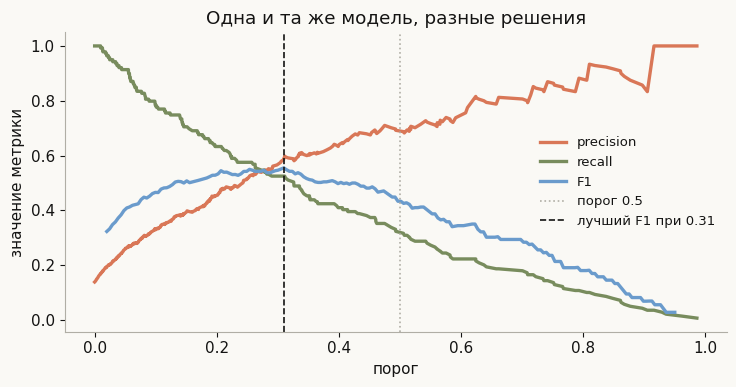

In [9]:
prec, rec, thr = precision_recall_curve(yb[te], proba)

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(thr, prec[:-1], color=C_ORANGE, lw=2.4, label="precision")
ax.plot(thr, rec[:-1], color=C_GREEN, lw=2.4, label="recall")
ax.plot(grid, f1s, color=C_BLUE, lw=2.4, label="F1")
ax.axvline(0.5, color=C_GRAY, lw=1.2, ls=":", label="порог 0.5")
ax.axvline(best_t, color=C_INK, lw=1.2, ls="--", label=f"лучший F1 при {best_t:.2f}")
ax.set_xlabel("порог")
ax.set_ylabel("значение метрики")
ax.set_title("Одна и та же модель, разные решения")
ax.legend(loc="center right", fontsize=9.5)
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
fig.tight_layout()

Модель одна, вероятности одни и те же — меняется только правило принятия решения. Это и есть смысл фразы «классификация = регрессия вероятности + порог».